In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import randint, uniform
import optuna
import joblib

from pprint import pprint

from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier, early_stopping

In [2]:
fe_train_df = pd.read_csv('data/fe_new/train.csv')
fe_val_df = pd.read_csv('data/fe_new/val.csv') 
fe_test_df = pd.read_csv('data/fe_new/test.csv')

In [3]:
fe2_fs_train_df = pd.read_csv('data/fe2_fs_new/train.csv')
fe2_fs_val_df = pd.read_csv('data/fe2_fs_new/val.csv')
fe2_fs_test_df = pd.read_csv('data/fe2_fs_new/test.csv')

In [4]:
def split_xy(df, target_col='SeriousDlqin2yrs'):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y

In [5]:
X_fe_train, y_fe_train = split_xy(fe_train_df)
X_fe_val, y_fe_val = split_xy(fe_val_df)
X_fe_test, y_fe_test = split_xy(fe_test_df)

In [6]:
X_fe2_fs_train, y_fe2_fs_train = split_xy(fe2_fs_train_df)
X_fe2_fs_val, y_fe2_fs_val = split_xy(fe2_fs_val_df)
X_fe2_fs_test, y_fe2_fs_test = split_xy(fe2_fs_test_df)

In [7]:
LOG_FEATURES_LOGREG = [
    'RevolvingUtilizationOfUnsecuredLines',
    'MonthlyIncome',
]

SCALE_FEATURES_LOGREG = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'NumberRealEstateLoansOrLines',
]

PASSTHROUGH_FEATURES_LOGREG = [ 
    'NumberOfOpenCreditLinesAndLoans', 
    'NumberOfTimes90DaysLate',
    'NumberOfDependents', 
    'MonthlyIncome_is_nan',
    'NumberOfDependents_is_nan', 
    'Revolving_high', 
    'Revolving_excess',
    'DebtRatio_high', 
    'Late_severity_log'
]

In [8]:
LOG_FEATURES_GB = [
    'MonthlyIncome',
]

PASSTHROUGH_FEATURES_GB = [ 
    'RevolvingUtilizationOfUnsecuredLines', 
    'age', 
    'NumberOfOpenCreditLinesAndLoans', 
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines', 
    'NumberOfDependents',
    'MonthlyIncome_is_nan', 
    'NumberOfDependents_is_nan', 
    'Revolving_high',
    'Revolving_excess', 
    'DebtRatio_high', 
    'Late_severity_log',
    'Late_per_credit', 
    'Is_old'
]

In [9]:
def log_features_logreg(X):
    X = X.copy()
    X[LOG_FEATURES_LOGREG] = np.log1p(X[LOG_FEATURES_LOGREG])
    return X

def log_features_gb(X):
    X = X.copy()
    X[LOG_FEATURES_GB] = np.log1p(X[LOG_FEATURES_GB])
    return X

In [10]:
def make_logreg_pipeline(model):
    scaler_block = ColumnTransformer(
        transformers=[
            ('scale', StandardScaler(), SCALE_FEATURES_LOGREG),
            ('keep', 'passthrough', PASSTHROUGH_FEATURES_LOGREG),
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )

    pipe = Pipeline([
        ('log', FunctionTransformer(log_features_logreg, validate=False)),
        ('scale', scaler_block),
        ('model', model)
    ])

    return pipe

In [11]:
def make_gb_pipeline(model):
    pipe = Pipeline([
        ('log', FunctionTransformer(log_features_gb, validate=False)),
        ('model', model)
    ])
    return pipe

In [12]:
def evaluate_model(
    model, 
    X, y,
    threshold=0.5
):
    probs = model.predict_proba(X)[:, 1]
    
    preds = (probs >= threshold).astype(int)

    metrics = {
        'BCE': log_loss(y, probs),
        'AUC': roc_auc_score(y, probs),
        'Accuracy': accuracy_score(y, preds),
        'Precision': precision_score(y, preds, zero_division=0),
        'Recall': recall_score(y, preds, zero_division=0),
        'F1': f1_score(y, preds, zero_division=0),
    }

    return metrics

In [13]:
gbm_pipe = make_gb_pipeline(
    GradientBoostingClassifier()
)

In [14]:
logreg_pipe = make_logreg_pipeline(
    LogisticRegression()
)

In [39]:
lgbm_pipe = make_gb_pipeline(
    LGBMClassifier(verbose=0)
)

In [16]:
gbm_pipe.fit(X_fe2_fs_train, y_fe2_fs_train)

gbm_metrics = evaluate_model(
    gbm_pipe,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_metrics)

{'AUC': 0.860399368750076,
 'Accuracy': 0.9368444444444445,
 'BCE': 0.17947528761293194,
 'F1': 0.29548834903321763,
 'Precision': 0.580896686159844,
 'Recall': 0.1981382978723404}


In [17]:
joblib.dump(gbm_pipe, 'models/GBM/gbm.joblib')

['models/GBM/gbm.joblib']

In [13]:
gbm_pipe = joblib.load('models/GBM/gbm.joblib')

In [18]:
logreg_pipe.fit(X_fe_train, y_fe_train)

logreg_metrics = evaluate_model(
    logreg_pipe,
    X_fe_test, y_fe_test
)
pprint(logreg_metrics)

{'AUC': 0.8570256891636908,
 'Accuracy': 0.9378222222222222,
 'BCE': 0.18837925424443214,
 'F1': 0.3001500750375188,
 'Precision': 0.6060606060606061,
 'Recall': 0.19946808510638298}


In [19]:
joblib.dump(logreg_pipe, 'models/LogReg/logreg.joblib')

['models/LogReg/logreg.joblib']

In [14]:
logreg_pipe = joblib.load('models/LogReg/logreg.joblib')

In [40]:
lgbm_pipe.fit(X_fe2_fs_train, y_fe2_fs_train)

lgbm_metrics = evaluate_model(
    lgbm_pipe,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(lgbm_metrics)

{'AUC': 0.860223835061795,
 'Accuracy': 0.9371555555555555,
 'BCE': 0.17913409666376748,
 'F1': 0.28585858585858587,
 'Precision': 0.5945378151260504,
 'Recall': 0.18816489361702127}


In [21]:
joblib.dump(lgbm_pipe, 'models/LGBM/lgbm.joblib')

['models/LGBM/lgbm.joblib']

In [15]:
lgbm_pipe = joblib.load('models/LGBM/lgbm.joblib')

In [13]:
def plot_roc_curve(model, model_name, X, y):
    plt.figure(figsize=(6, 6))
    probs = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, probs)
    auc_score = roc_auc_score(y, probs)

    plt.plot(fpr, tpr, label=f'AUC={auc_score:.4f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC-AUC')
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(alpha=0.3)
    plt.show()

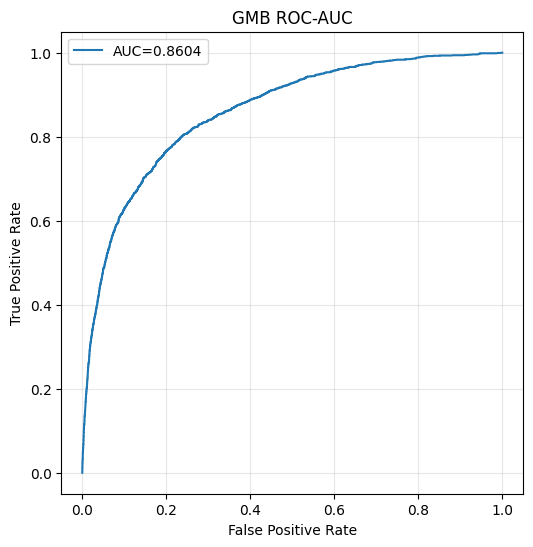

In [23]:
plot_roc_curve(gbm_pipe, 'GMB', X_fe2_fs_test, y_fe2_fs_test)

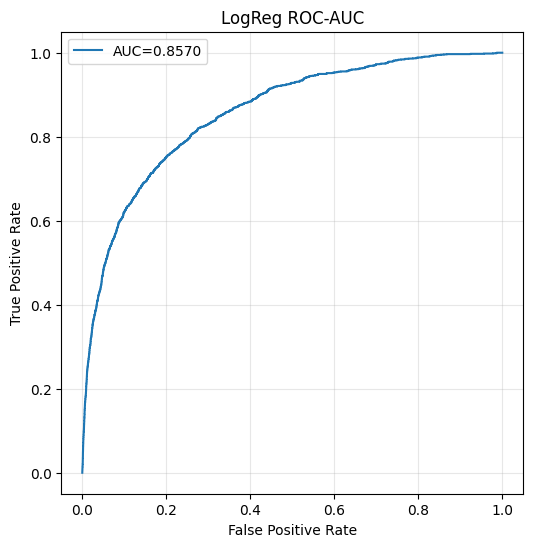

In [24]:
plot_roc_curve(logreg_pipe, 'LogReg', X_fe_test, y_fe_test)

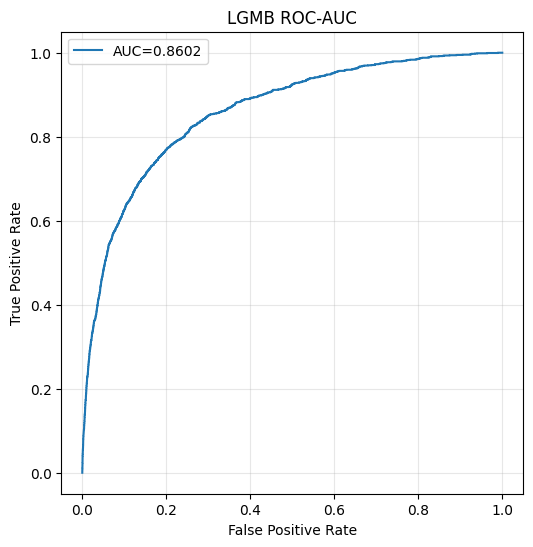

In [25]:
plot_roc_curve(lgbm_pipe, 'LGMB', X_fe2_fs_test, y_fe2_fs_test)

In [26]:
metrics_dict = {
    'GBM': gbm_metrics,
    'LogReg': logreg_metrics,
    'LGBM': lgbm_metrics
}

In [14]:
def plot_metrics_from_dicts(metrics_dict):
    metrics = ['BCE', 'AUC', 'F1', 'Accuracy', 'Precision', 'Recall']

    df = pd.DataFrame(metrics_dict).T
    df = df[metrics]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        values = df[metric]
        models = df.index

        if metric == 'BCE':
            best_model = values.idxmin()
        else:
            best_model = values.idxmax()

        colors = ['tab:orange' if model == best_model else 'tab:blue' for model in models]

        ax.bar(models, values, color=colors)

        y_min = values.min()
        y_max = values.max()
        margin = (y_max - y_min) * 0.3 if y_max != y_min else 0.01
        ax.set_ylim(y_min - margin, y_max + margin)

        ax.set_title(metric)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=20)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

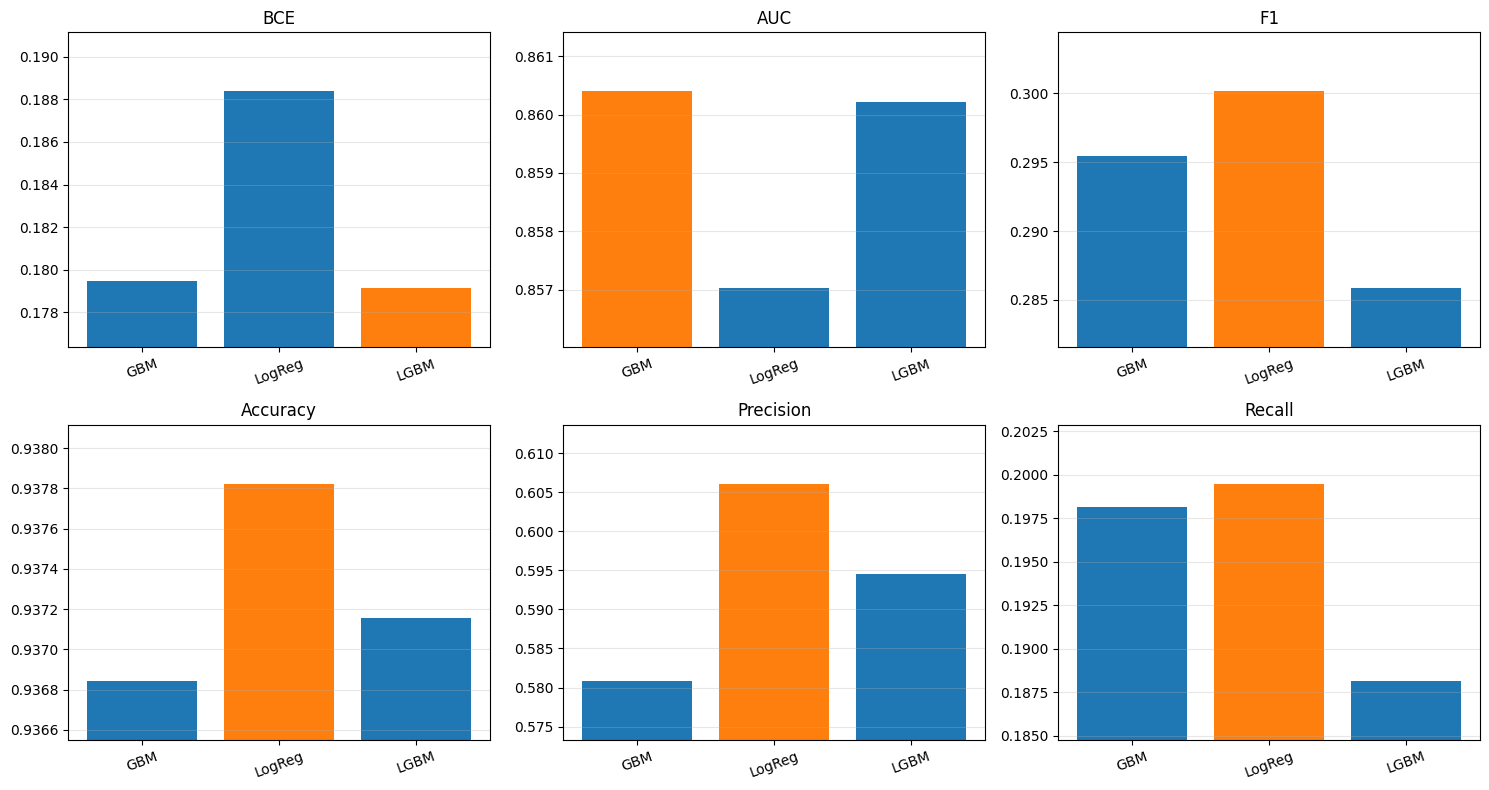

In [28]:
plot_metrics_from_dicts(metrics_dict)

In [29]:
gbm_pipe_gscv = make_gb_pipeline(
    GradientBoostingClassifier(random_state=42)
)

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.8, 1.0],
}

grid = GridSearchCV(
    estimator=gbm_pipe_gscv,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=0
)


grid.fit(X_fe2_fs_train, y_fe2_fs_train)
print(f'Лучшие параметры: {grid.best_params_}')

gbm_pipe_gscv = grid.best_estimator_

gbm_gscv_metrics = evaluate_model(
    gbm_pipe_gscv,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_gscv_metrics)

Лучшие параметры: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
{'AUC': 0.861645236757356,
 'Accuracy': 0.9365333333333333,
 'BCE': 0.17910813518592633,
 'F1': 0.2736520854526958,
 'Precision': 0.5822510822510822,
 'Recall': 0.17885638297872342}


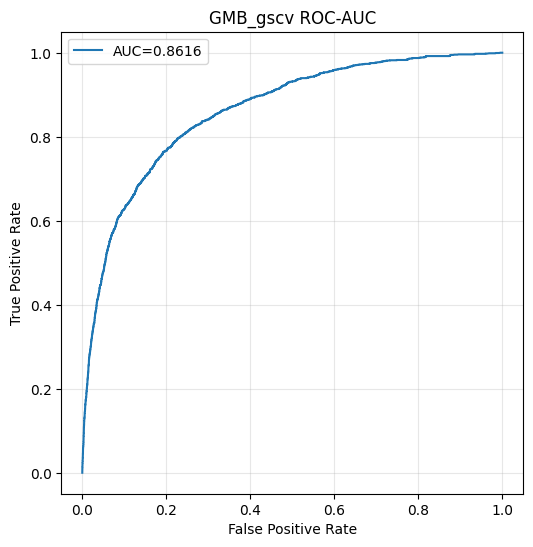

In [37]:
plot_roc_curve(gbm_pipe_gscv, 'GMB_gscv', X_fe2_fs_test, y_fe2_fs_test)

In [31]:
joblib.dump(gbm_pipe_gscv, 'models/GBM/gbm_gscv.joblib')

['models/GBM/gbm_gscv.joblib']

In [18]:
gbm_pipe_gscv = joblib.load('models/GBM/gbm_gscv.joblib')

In [31]:
def objective_gbm(trial):
    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'model__max_depth': trial.suggest_int('max_depth', 2, 5),
        'model__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'model__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30), 
        'model__random_state': 42
    }

    pipe = make_gb_pipeline(
        GradientBoostingClassifier()
    )

    pipe.set_params(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(
        pipe,
        X_fe2_fs_train,
        y_fe2_fs_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return score

In [32]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_gbm, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


gbm_pipe_optuna = make_gb_pipeline(
    GradientBoostingClassifier()
)
gbm_pipe_optuna.set_params(**best_params)

gbm_pipe_optuna.fit(X_fe2_fs_train, y_fe2_fs_train) 

gbm_optuna_metrics = evaluate_model(
    gbm_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_optuna_metrics)

[I 2026-03-31 19:56:06,229] A new study created in memory with name: no-name-7685c290-dd22-4f6b-96f6-55d0a3de437e
[I 2026-03-31 19:56:50,702] Trial 0 finished with value: 0.8602882636768443 and parameters: {'n_estimators': 309, 'learning_rate': 0.16340264222956638, 'max_depth': 4, 'subsample': 0.8222464271731171, 'min_samples_split': 17, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.8602882636768443.
[I 2026-03-31 19:58:09,913] Trial 1 finished with value: 0.8632892264725113 and parameters: {'n_estimators': 383, 'learning_rate': 0.012480849011798236, 'max_depth': 5, 'subsample': 0.8333836044544054, 'min_samples_split': 30, 'min_samples_leaf': 27}. Best is trial 1 with value: 0.8632892264725113.
[I 2026-03-31 19:58:23,197] Trial 2 finished with value: 0.863075366072386 and parameters: {'n_estimators': 147, 'learning_rate': 0.150144595583845, 'max_depth': 2, 'subsample': 0.9827571811477585, 'min_samples_split': 26, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.86328922647

Лучшие параметры: {'model__n_estimators': 251, 'model__learning_rate': 0.09618537688479904, 'model__max_depth': 3, 'model__subsample': 0.8083583951708886, 'model__min_samples_split': 36, 'model__min_samples_leaf': 25}
{'AUC': 0.86133872574006,
 'Accuracy': 0.9362222222222222,
 'BCE': 0.17925950417598496,
 'F1': 0.27415275670207384,
 'Precision': 0.572938689217759,
 'Recall': 0.18018617021276595}


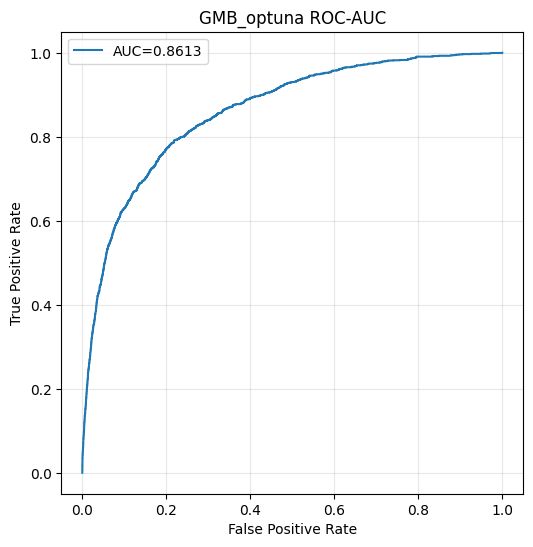

In [33]:
plot_roc_curve(gbm_pipe_optuna, 'GMB_optuna', X_fe2_fs_test, y_fe2_fs_test)

In [34]:
joblib.dump(gbm_pipe_optuna, 'models/GBM/gbm_optuna.joblib')

['models/GBM/gbm_optuna.joblib']

In [19]:
gbm_pipe_optuna = joblib.load('models/GBM/gbm_optuna.joblib')

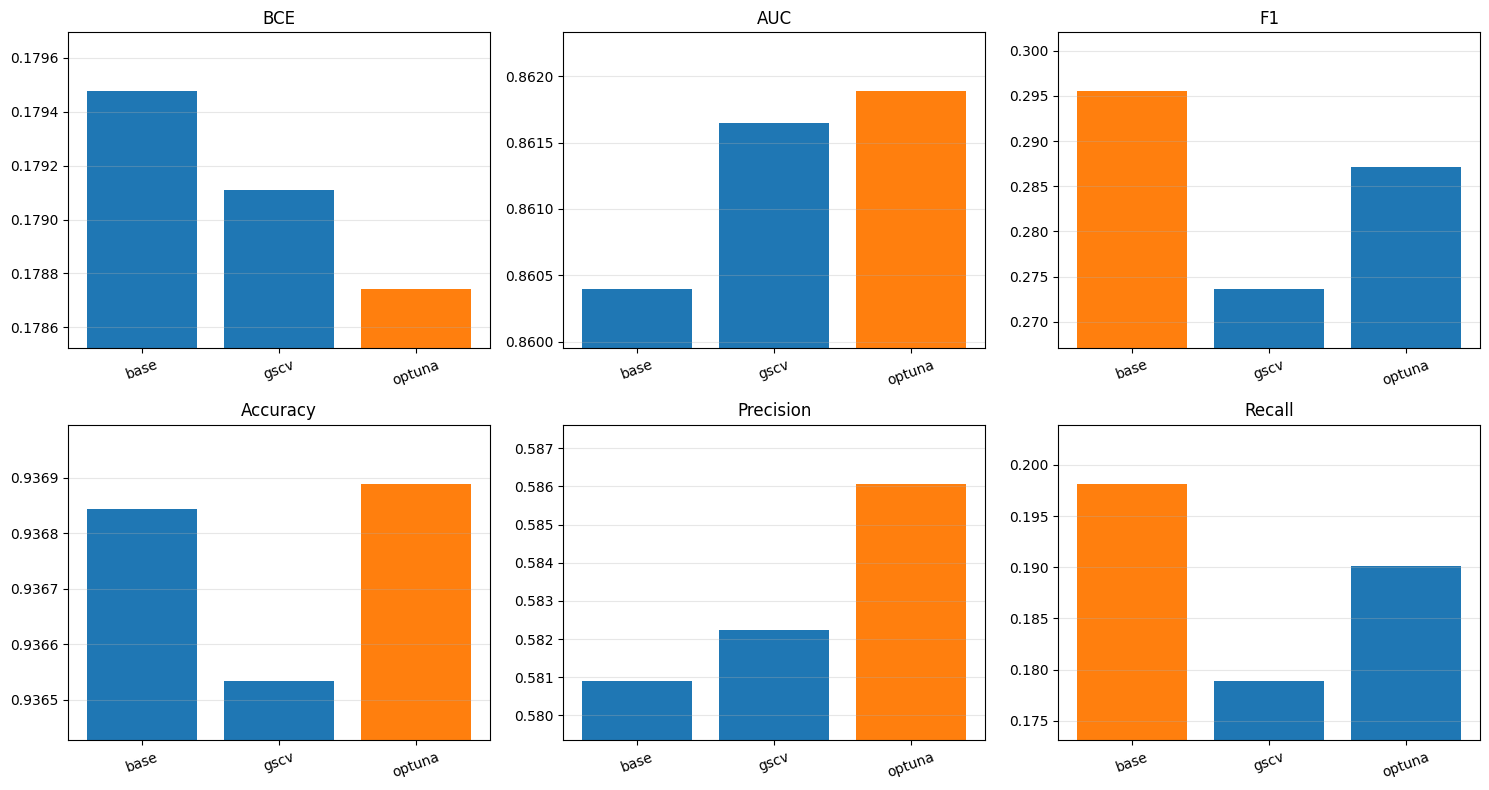

In [35]:
metrics_dict = {
    'base': gbm_metrics,
    'gscv': gbm_gscv_metrics,
    'optuna': gbm_optuna_metrics
}

plot_metrics_from_dicts(metrics_dict)

In [39]:
logreg_pipe_gscv = make_logreg_pipeline(
    LogisticRegression()
)

param_grid = [
    {
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'liblinear'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced'],
    },
    {
        'model__penalty': ['l1'],
        'model__solver': ['liblinear'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced'],
    }
]

grid = GridSearchCV(
    estimator=logreg_pipe_gscv,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=0
)


grid.fit(X_fe_train, y_fe_train)
print(f'Лучшие параметры: {grid.best_params_}')

logreg_pipe_gscv = grid.best_estimator_

logreg_gscv_metrics = evaluate_model(
    logreg_pipe_gscv,
    X_fe_test, y_fe_test
)
pprint(logreg_gscv_metrics)

Лучшие параметры: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
{'AUC': 0.8571298756754073,
 'Accuracy': 0.8076888888888889,
 'BCE': 0.47822902727553407,
 'F1': 0.33928844098335625,
 'Precision': 0.22021803766105055,
 'Recall': 0.7386968085106383}


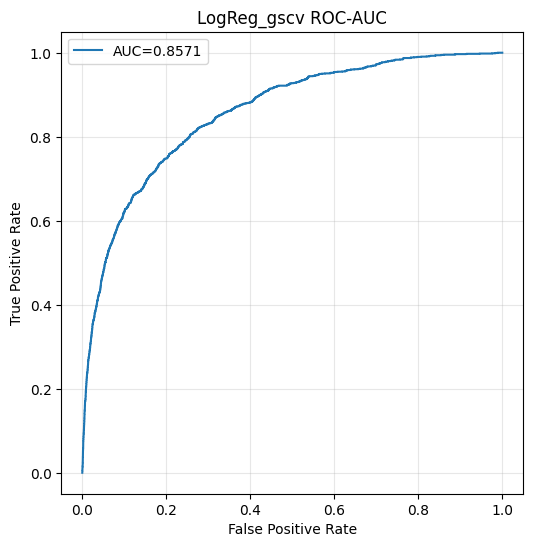

In [40]:
plot_roc_curve(logreg_pipe_gscv, 'LogReg_gscv', X_fe_test, y_fe_test)

In [41]:
joblib.dump(logreg_pipe_gscv, 'models/LogReg/logreg_gscv.joblib')

['models/LogReg/logreg_gscv.joblib']

In [20]:
logreg_pipe_gscv = joblib.load('models/LogReg/logreg_gscv.joblib')

In [46]:
def objective_logreg(trial):
    params = {
        'model__C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'model__penalty': 'l2',
        'model__solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
        'model__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'model__max_iter': 2000,
        'model__random_state': 42
    }

    pipe = make_logreg_pipeline(
        LogisticRegression()
    )

    pipe.set_params(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        pipe,
        X_fe_train,
        y_fe_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return score

In [47]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_logreg, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


logreg_pipe_optuna = make_logreg_pipeline(
    LogisticRegression()
)
logreg_pipe_optuna.set_params(**best_params)

logreg_pipe_optuna.fit(X_fe_train, y_fe_train) 

logreg_optuna_metrics = evaluate_model(
    logreg_pipe_optuna,
    X_fe_test, y_fe_test
)
pprint(logreg_optuna_metrics)

[I 2026-03-29 15:15:13,766] A new study created in memory with name: no-name-6ef02bd7-e0a6-4daf-b7b4-23589b23d0b6
[I 2026-03-29 15:15:16,185] Trial 0 finished with value: 0.8576649745001614 and parameters: {'C': 2.735672342435542, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8576649745001614.
[I 2026-03-29 15:15:18,193] Trial 1 finished with value: 0.8576172485258386 and parameters: {'C': 0.008487893186348223, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8576649745001614.
[I 2026-03-29 15:15:19,969] Trial 2 finished with value: 0.8576652287301261 and parameters: {'C': 11.886668897982327, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.8576652287301261.
[I 2026-03-29 15:15:20,594] Trial 3 finished with value: 0.8576648434450647 and parameters: {'C': 6.0041728152057985, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.8576652287301261.
[I 2026-03-29

Лучшие параметры: {'model__C': 1.122335007193969, 'model__solver': 'lbfgs', 'model__class_weight': 'balanced'}
{'AUC': 0.85713614586669,
 'Accuracy': 0.8076888888888889,
 'BCE': 0.47811861342863193,
 'F1': 0.3390866045517031,
 'Precision': 0.2201070791195717,
 'Recall': 0.738031914893617}


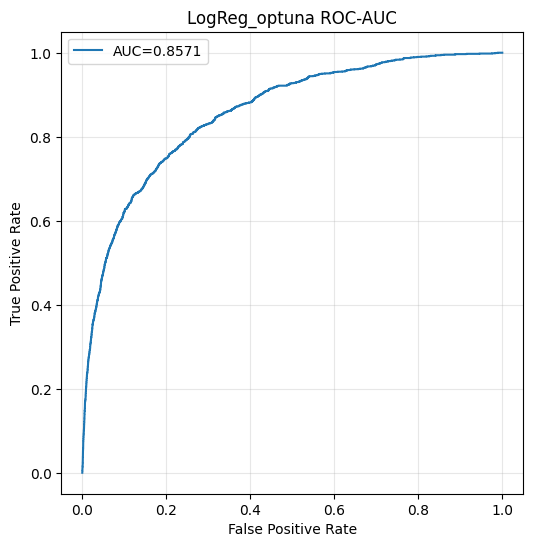

In [48]:
plot_roc_curve(logreg_pipe_optuna, 'LogReg_optuna', X_fe_test, y_fe_test)

In [49]:
joblib.dump(logreg_pipe_optuna, 'models/LogReg/logreg_optuna.joblib')

['models/LogReg/logreg_optuna.joblib']

In [21]:
logreg_pipe_optuna = joblib.load('models/LogReg/logreg_optuna.joblib')

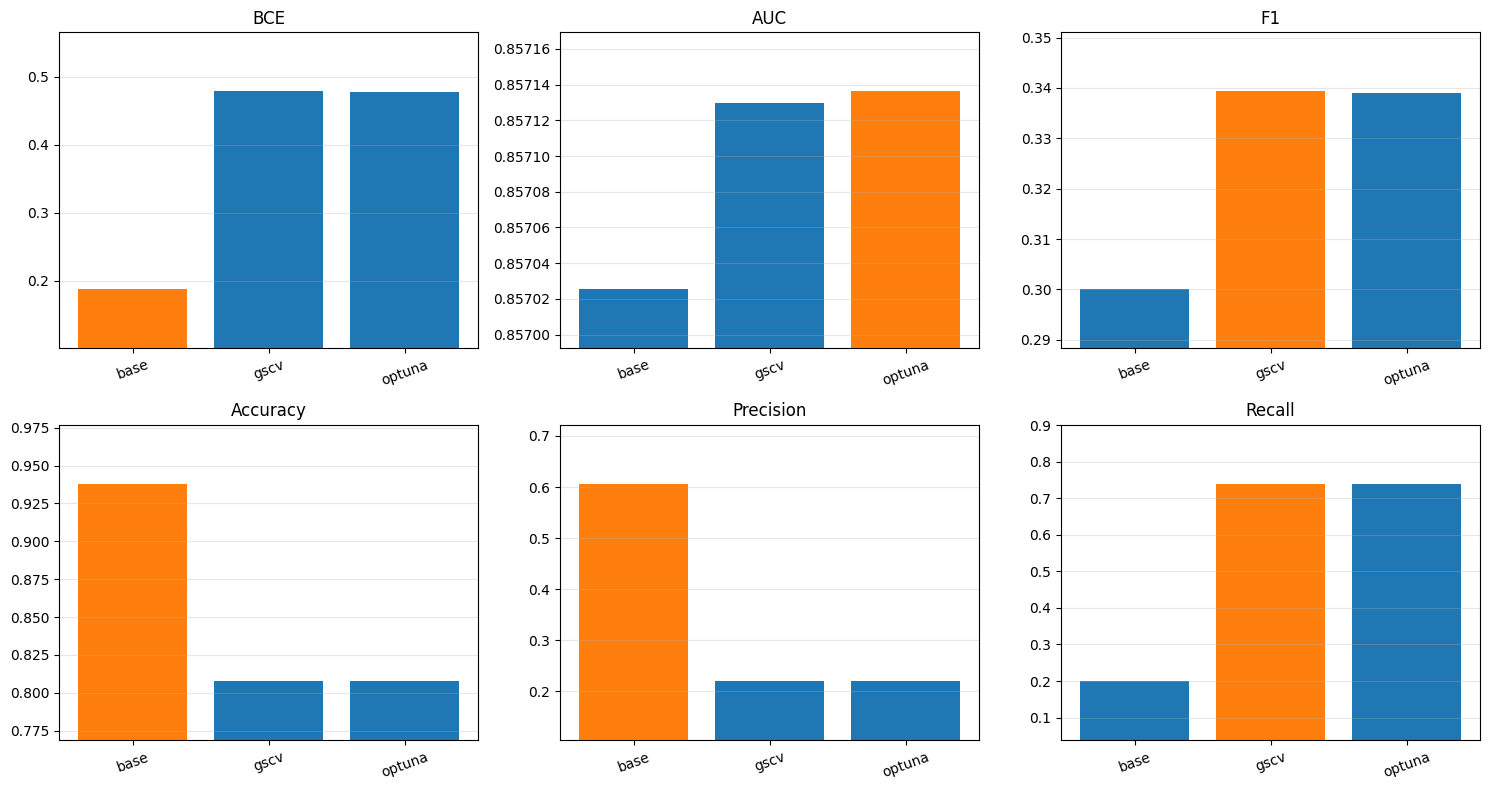

In [50]:
metrics_dict = {
    'base': logreg_metrics,
    'gscv': logreg_gscv_metrics,
    'optuna': logreg_optuna_metrics
}

plot_metrics_from_dicts(metrics_dict)

In [35]:
def objective_lgbm(trial):
    max_depth = trial.suggest_int('max_depth', 3, 6)
    max_leaves = min(2 ** max_depth, 64)

    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': max_depth,
        'model__num_leaves': trial.suggest_int('num_leaves', 4, max_leaves),
        'model__subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'model__min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'model__reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'model__reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'model__random_state': 42,
        'model__verbose': 0,
        'model__objective': 'binary',
        'model__n_jobs': -1
    }

    pipe = make_gb_pipeline(
        LGBMClassifier()
    )

    pipe.set_params(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(
        pipe,
        X_fe2_fs_train,
        y_fe2_fs_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return score

In [36]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_lgbm, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


lgbm_pipe_optuna = make_gb_pipeline(
    LGBMClassifier()
)
lgbm_pipe_optuna.set_params(**best_params)

lgbm_pipe_optuna.fit(X_fe2_fs_train, y_fe2_fs_train) 

lgbm_optuna_metrics = evaluate_model(
    lgbm_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(lgbm_optuna_metrics)

[I 2026-03-31 20:24:57,640] A new study created in memory with name: no-name-86688c37-aa1d-4a1a-924b-a4cbd1d54114
[I 2026-03-31 20:26:04,846] Trial 0 finished with value: 0.8596984666891752 and parameters: {'max_depth': 3, 'n_estimators': 77, 'learning_rate': 0.047005680957507796, 'num_leaves': 5, 'subsample': 0.7273806593173654, 'colsample_bytree': 0.7261778858943913, 'min_child_samples': 35, 'reg_alpha': 0.0008241116910172538, 'reg_lambda': 1.6976347433514576}. Best is trial 0 with value: 0.8596984666891752.
[I 2026-03-31 20:29:26,147] Trial 1 finished with value: 0.8640108420376883 and parameters: {'max_depth': 3, 'n_estimators': 243, 'learning_rate': 0.05454418401138403, 'num_leaves': 5, 'subsample': 0.9441447860707622, 'colsample_bytree': 0.795918751280202, 'min_child_samples': 96, 'reg_alpha': 0.206758088706637, 'reg_lambda': 0.0001318522353424438}. Best is trial 1 with value: 0.8640108420376883.
[I 2026-03-31 20:40:38,032] Trial 2 finished with value: 0.8614067575015781 and para

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-31 21:13:18,731] Trial 6 finished with value: 0.8625008743637587 and parameters: {'max_depth': 6, 'n_estimators': 230, 'learning_rate': 0.02166084913391771, 'num_leaves': 57, 'subsample': 0.8714178018917168, 'colsample_bytree': 0.8378862900774569, 'min_child_samples': 77, 'reg_alpha': 0.13593266781204053, 'reg_lambda': 0.005231627677213716}. Best is trial 5 with value: 0.8643195379689861.
[I 2026-03-31 21:17:05,054] Trial 7 finished with value: 0.8647560846772631 and parameters: {'max_depth': 3, 'n_estimators': 237, 'learning_rate': 0.11637136723230176, 'num_leaves': 6, 'subsample': 0.9914796113217696, 'colsample_bytree': 0.7472109041575529, 'min_child_samples': 47, 'reg_alpha': 0.004822064307659261, 'reg_lambda': 6.6454896829767165}. Best is trial 7 with value: 0.8647560846772631.
[I 2026-03-31 21:19:11,067] Trial 8 finished with value: 0.8644283131316624 and parameters: {'max_depth': 4, 'n_estimators': 141, 'learning_rate': 0.14004154292835114, 'num_leaves': 5, 'subsample'

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-31 21:31:01,379] Trial 10 finished with value: 0.8646635539607266 and parameters: {'max_depth': 4, 'n_estimators': 268, 'learning_rate': 0.08256124911473676, 'num_leaves': 11, 'subsample': 0.9907217508670392, 'colsample_bytree': 0.7847472821076396, 'min_child_samples': 46, 'reg_alpha': 3.3239062056816713, 'reg_lambda': 0.052891307891150215}. Best is trial 7 with value: 0.8647560846772631.
[I 2026-03-31 21:39:46,127] Trial 11 finished with value: 0.8648421917330211 and parameters: {'max_depth': 4, 'n_estimators': 289, 'learning_rate': 0.08037149962017302, 'num_leaves': 12, 'subsample': 0.984616461716718, 'colsample_bytree': 0.7661628771105257, 'min_child_samples': 45, 'reg_alpha': 8.74986632136288, 'reg_lambda': 0.042481154610906506}. Best is trial 11 with value: 0.8648421917330211.
[I 2026-03-31 21:48:51,140] Trial 12 finished with value: 0.8633215975858161 and parameters: {'max_depth': 4, 'n_estimators': 296, 'learning_rate': 0.09148341479034222, 'num_leaves': 12, 'subsampl

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-04-01 10:25:05,773] Trial 38 finished with value: 0.8636677731839179 and parameters: {'max_depth': 5, 'n_estimators': 140, 'learning_rate': 0.03316836034696816, 'num_leaves': 15, 'subsample': 0.9761345703393345, 'colsample_bytree': 0.7195132606721064, 'min_child_samples': 78, 'reg_alpha': 3.593883773320098, 'reg_lambda': 0.09332402620363367}. Best is trial 11 with value: 0.8648421917330211.
[I 2026-04-01 10:29:15,503] Trial 39 finished with value: 0.8649227166051927 and parameters: {'max_depth': 3, 'n_estimators': 264, 'learning_rate': 0.14823265459498267, 'num_leaves': 6, 'subsample': 0.8784436548516388, 'colsample_bytree': 0.8478236432117398, 'min_child_samples': 55, 'reg_alpha': 8.059519272952402, 'reg_lambda': 0.6812239339844494}. Best is trial 39 with value: 0.8649227166051927.
[I 2026-04-01 10:33:17,754] Trial 40 finished with value: 0.8650083158890938 and parameters: {'max_depth': 3, 'n_estimators': 262, 'learning_rate': 0.1413508285255956, 'num_leaves': 6, 'subsample': 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-04-01 11:04:54,475] Trial 49 finished with value: 0.8649017582708781 and parameters: {'max_depth': 3, 'n_estimators': 215, 'learning_rate': 0.1485667578844103, 'num_leaves': 6, 'subsample': 0.8045466070035536, 'colsample_bytree': 0.8510975437509705, 'min_child_samples': 57, 'reg_alpha': 8.79215015747132, 'reg_lambda': 0.09801226957294182}. Best is trial 41 with value: 0.8650773807874778.


Лучшие параметры: {'model__max_depth': 3, 'model__n_estimators': 262, 'model__learning_rate': 0.14326912575389047, 'model__num_leaves': 6, 'model__subsample': 0.8770904616087901, 'model__colsample_bytree': 0.8862157032760253, 'model__min_child_samples': 54, 'model__reg_alpha': 7.9187181936799576, 'model__reg_lambda': 0.6752289087146363}
[LightGBM] [Info] Number of positive: 7018, number of negative: 97982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 867
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066838 -> initscore=-2.636306
[LightGBM] [Info] Start training from score -2.636306
{'AUC': 0.8625237127233961,
 'Accuracy': 0.9376444444444444,
 'BCE': 0.1779775587386434,
 'F1': 0.298149

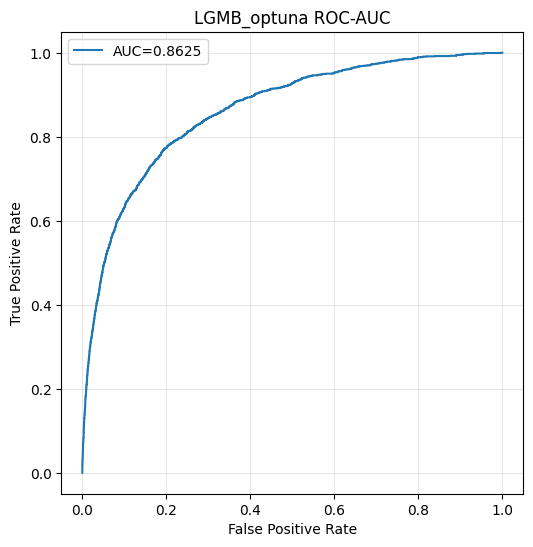

In [38]:
plot_roc_curve(lgbm_pipe_optuna, 'LGMB_optuna', X_fe2_fs_test, y_fe2_fs_test)

In [37]:
joblib.dump(lgbm_pipe_optuna, 'models/LGBM/lgbm_optuna.joblib')

['models/LGBM/lgbm_optuna.joblib']

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
lgbm_pipe_optuna = joblib.load('models/LGBM/lgbm_optuna.joblib')

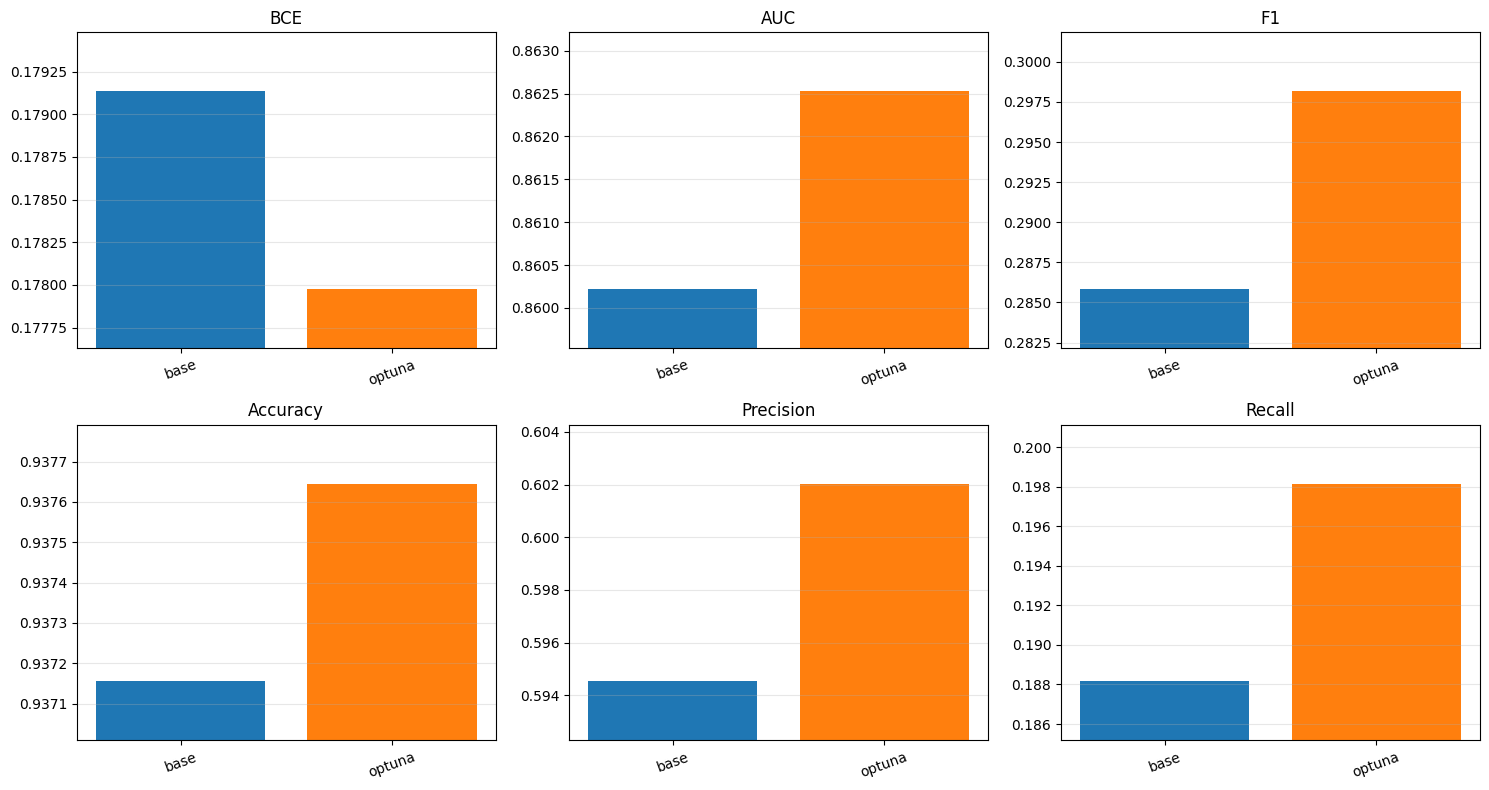

In [41]:
metrics_dict = {
    'base': lgbm_metrics,
    'optuna': lgbm_optuna_metrics
}

plot_metrics_from_dicts(metrics_dict)

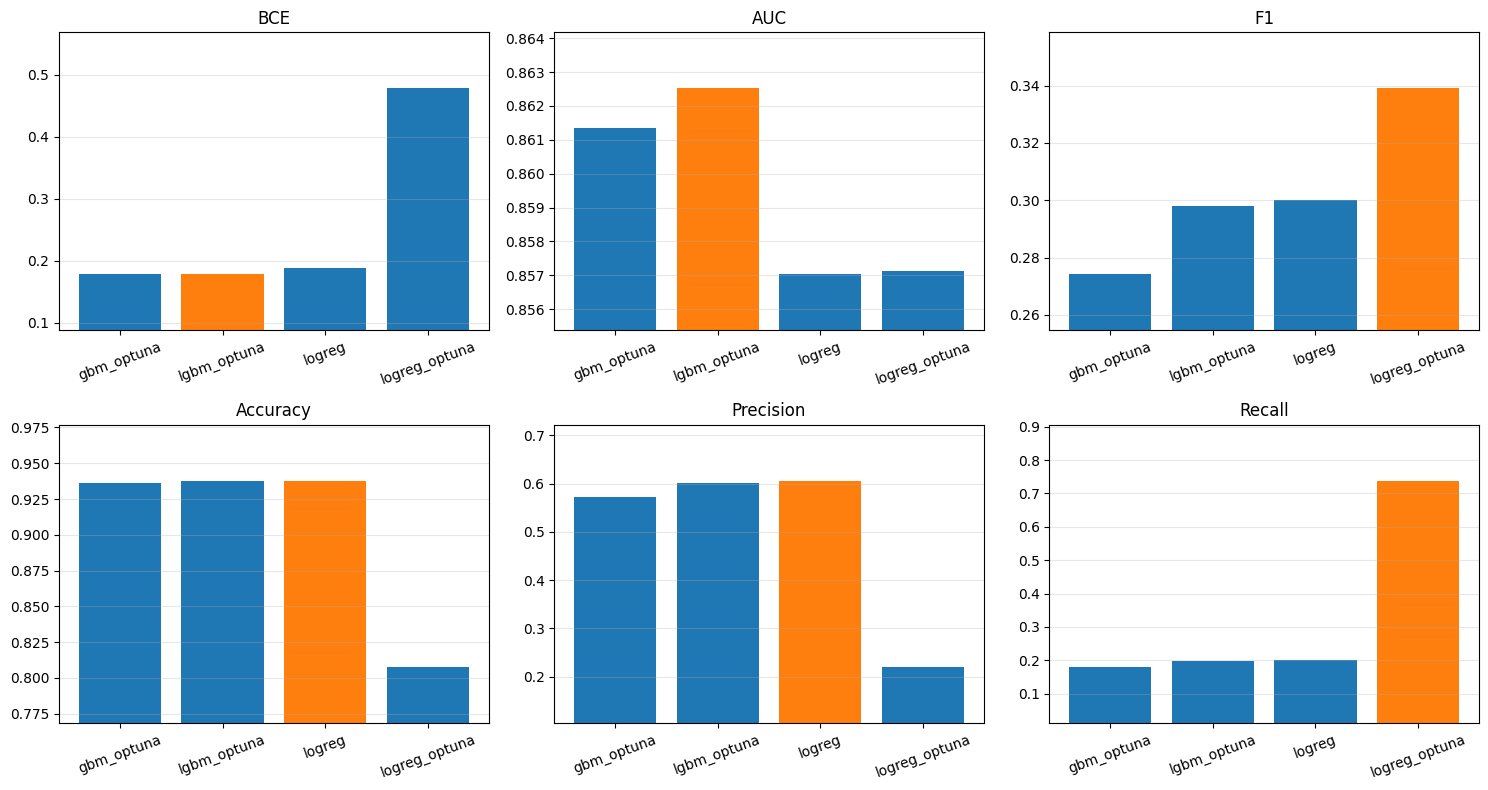

In [21]:
gbm_pipe_optuna = joblib.load('models/GBM/gbm_optuna.joblib')
logreg_pipe = joblib.load('models/LogReg/logreg.joblib')
logreg_pipe_optuna = joblib.load('models/LogReg/logreg_optuna.joblib')
lgbm_pipe_optuna = joblib.load('models/LGBM/lgbm_optuna.joblib')

gb_models = {'gbm_optuna': gbm_pipe_optuna, 'lgbm_optuna': lgbm_pipe_optuna}
logreg_models = {'logreg': logreg_pipe, 'logreg_optuna': logreg_pipe_optuna}

metrics_dict = {}


for model_name, model in gb_models.items(): 
    metrics = evaluate_model(
        model,
        X_fe2_fs_test, y_fe2_fs_test
    )
    metrics_dict[model_name] = metrics

for model_name, model in logreg_models.items(): 
    metrics = evaluate_model(
        model,
        X_fe_test, y_fe_test
    )
    metrics_dict[model_name] = metrics

plot_metrics_from_dicts(metrics_dict)

In [45]:
def objective_gbm_val(trial):
    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'model__max_depth': trial.suggest_int('max_depth', 2, 5),
        'model__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'model__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'model__max_features': trial.suggest_categorical(
            'max_features',
            [None, 'sqrt', 'log2']
        ),
        'model__loss': trial.suggest_categorical(
            'loss',
            ['log_loss', 'exponential']
        ),
        'model__random_state': 42
    }

    pipe = make_gb_pipeline(
        GradientBoostingClassifier()
    )

    pipe.set_params(**params)
    pipe.fit(X_fe2_fs_train, y_fe2_fs_train)

    val_probs = pipe.predict_proba(X_fe2_fs_val)[:, 1]
    val_auc = roc_auc_score(y_fe2_fs_val, val_probs)

    return val_auc

In [47]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_gbm_val, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


gbm_val_pipe_optuna = make_gb_pipeline(
    GradientBoostingClassifier()
)
gbm_val_pipe_optuna.set_params(**best_params)

gbm_val_pipe_optuna.fit(X_fe2_fs_train, y_fe2_fs_train) 

gbm_val_optuna_metrics = evaluate_model(
    gbm_val_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_val_optuna_metrics)

[I 2026-04-01 12:47:07,026] A new study created in memory with name: no-name-c1e44daf-a235-4e06-8b08-4cc3fdbdcc0b
[I 2026-04-01 12:47:14,206] Trial 0 finished with value: 0.8670611303115487 and parameters: {'n_estimators': 312, 'learning_rate': 0.018503373515257875, 'max_depth': 3, 'subsample': 0.8268310089129288, 'min_samples_split': 37, 'min_samples_leaf': 28, 'max_features': 'sqrt', 'loss': 'exponential'}. Best is trial 0 with value: 0.8670611303115487.
[I 2026-04-01 12:47:25,873] Trial 1 finished with value: 0.8682633761547286 and parameters: {'n_estimators': 81, 'learning_rate': 0.04761936276832094, 'max_depth': 5, 'subsample': 0.7241441309122895, 'min_samples_split': 49, 'min_samples_leaf': 27, 'max_features': None, 'loss': 'exponential'}. Best is trial 1 with value: 0.8682633761547286.
[I 2026-04-01 12:47:35,381] Trial 2 finished with value: 0.8697347810423869 and parameters: {'n_estimators': 310, 'learning_rate': 0.10005629029329435, 'max_depth': 4, 'subsample': 0.8983018669893

Лучшие параметры: {'model__n_estimators': 211, 'model__learning_rate': 0.06988839966435516, 'model__max_depth': 4, 'model__subsample': 0.8271231122262597, 'model__min_samples_split': 29, 'model__min_samples_leaf': 24, 'model__max_features': 'sqrt', 'model__loss': 'exponential'}
{'AUC': 0.8629723322426156,
 'Accuracy': 0.9373333333333334,
 'BCE': 0.17800396920144693,
 'F1': 0.28643724696356276,
 'Precision': 0.5995762711864406,
 'Recall': 0.18816489361702127}


In [59]:
joblib.dump(gbm_val_pipe_optuna, 'models/GBM/gbm_val_optuna.joblib')

['models/GBM/gbm_val_optuna.joblib']

In [16]:
gbm_val_pipe_optuna = joblib.load('models/GBM/gbm_val_optuna.joblib')

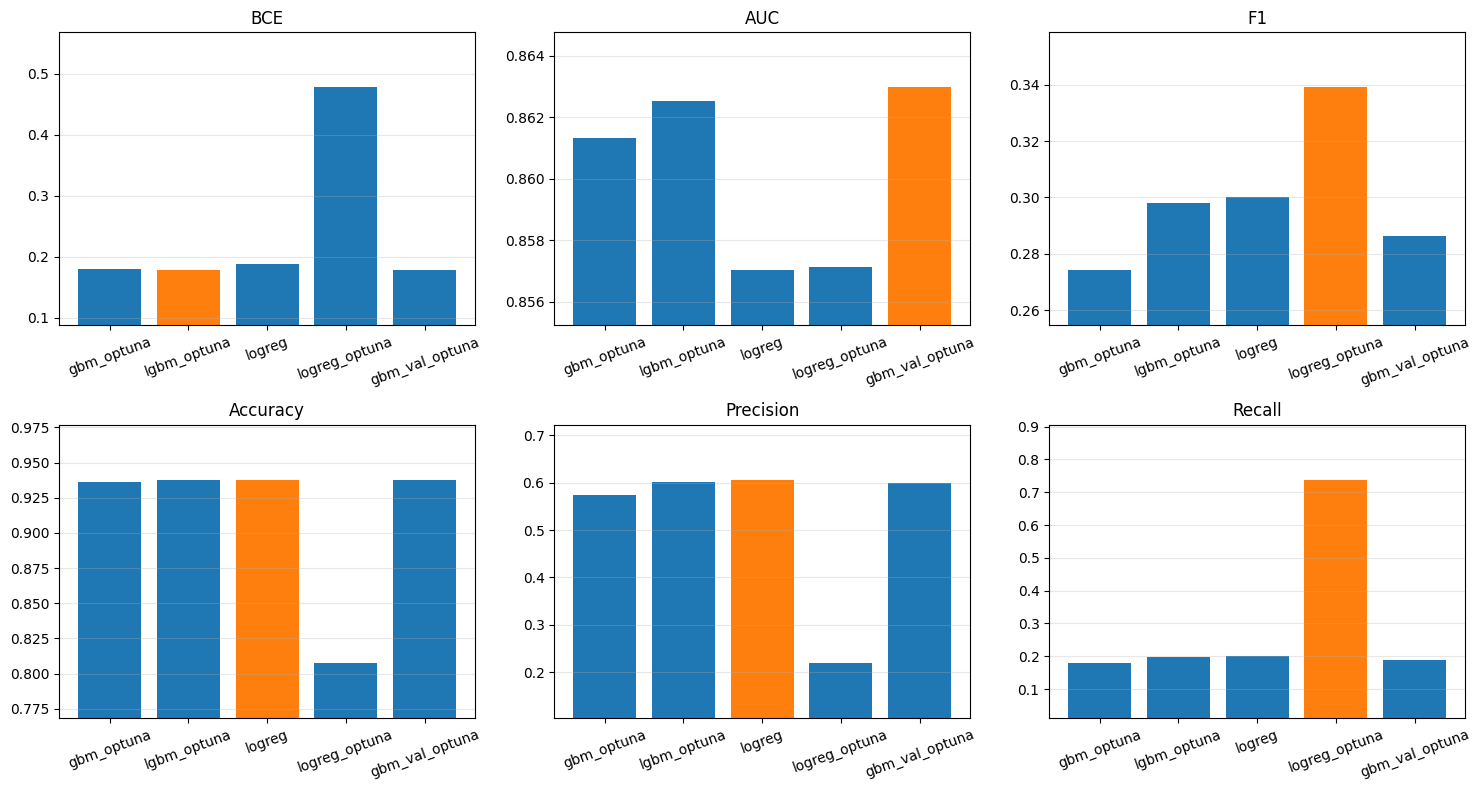

In [24]:
metrics_dict['gbm_val_optuna'] = gbm_val_optuna_metrics
plot_metrics_from_dicts(metrics_dict)

In [57]:
def objective_lgbm_val(trial):
    max_depth = trial.suggest_int('max_depth', 3, 6)

    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'model__max_depth': max_depth,
        'model__num_leaves': trial.suggest_int('num_leaves', 4, min(2 ** max_depth, 64)),
        'model__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'model__min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'model__reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'model__reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'model__random_state': 42,
        'model__verbosity': -1,
        'model__objective': 'binary',
        'model__n_jobs': 1
    }

    pipe = make_gb_pipeline(
        LGBMClassifier()
    )

    pipe.set_params(**params)


    pipe.fit(
        X_fe2_fs_train,
        y_fe2_fs_train,
        model__eval_set=[(X_fe2_fs_val, y_fe2_fs_val)],
        model__eval_metric='auc'
    )

    val_probs = pipe.predict_proba(X_fe2_fs_val)[:, 1]
    val_auc = roc_auc_score(y_fe2_fs_val, val_probs)

    return val_auc

In [58]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_lgbm_val, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')

lgbm_val_pipe_optuna = make_gb_pipeline(
    LGBMClassifier()
)
lgbm_val_pipe_optuna.set_params(**best_params)

lgbm_val_pipe_optuna.fit(
    X_fe2_fs_train,
    y_fe2_fs_train,
    model__eval_set=[(X_fe2_fs_val, y_fe2_fs_val)],
    model__eval_metric='auc'
)

lgbm_val_optuna_metrics = evaluate_model(
    lgbm_val_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(lgbm_val_optuna_metrics)

[I 2026-04-01 20:41:29,694] A new study created in memory with name: no-name-671d763d-070e-4c58-afb7-a1ef573c6c8e
[I 2026-04-01 20:41:32,746] Trial 0 finished with value: 0.8703295466867043 and parameters: {'max_depth': 3, 'n_estimators': 468, 'learning_rate': 0.04746102398031976, 'num_leaves': 7, 'subsample': 0.7217047300868654, 'colsample_bytree': 0.8711480505921935, 'min_child_samples': 61, 'reg_alpha': 0.050310645992791676, 'reg_lambda': 0.0007868462316412455}. Best is trial 0 with value: 0.8703295466867043.
[I 2026-04-01 20:41:34,967] Trial 1 finished with value: 0.8685853726444348 and parameters: {'max_depth': 3, 'n_estimators': 318, 'learning_rate': 0.02469985318721273, 'num_leaves': 6, 'subsample': 0.6177827403629903, 'colsample_bytree': 0.63821930222147, 'min_child_samples': 64, 'reg_alpha': 0.0005577165775847247, 'reg_lambda': 0.19994667111639566}. Best is trial 0 with value: 0.8703295466867043.
[I 2026-04-01 20:41:36,586] Trial 2 finished with value: 0.8705509351071937 and p

Лучшие параметры: {'model__max_depth': 4, 'model__n_estimators': 223, 'model__learning_rate': 0.08103861077486735, 'model__num_leaves': 8, 'model__subsample': 0.6075527180557759, 'model__colsample_bytree': 0.7148129800673837, 'model__min_child_samples': 49, 'model__reg_alpha': 1.8174245866111363, 'model__reg_lambda': 0.07938535792165825}
{'AUC': 0.8624970802442614,
 'Accuracy': 0.9377333333333333,
 'BCE': 0.1780753169375849,
 'F1': 0.291350531107739,
 'Precision': 0.6088794926004228,
 'Recall': 0.19148936170212766}


In [60]:
joblib.dump(lgbm_val_pipe_optuna, 'models/LGBM/lgbm_val_optuna.joblib')

['models/LGBM/lgbm_val_optuna.joblib']

In [17]:
lgbm_val_pipe_optuna = joblib.load('models/LGBM/lgbm_val_optuna.joblib')

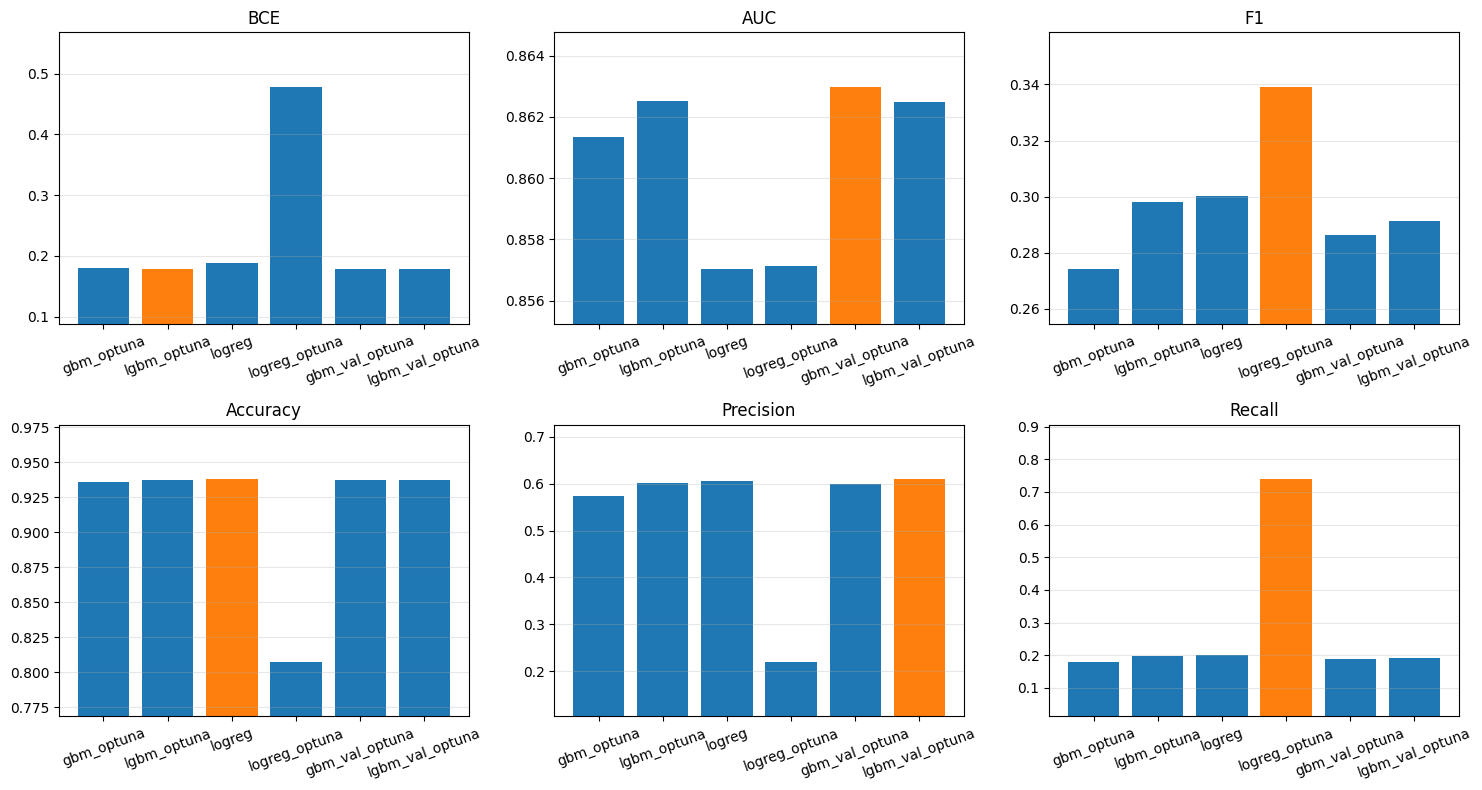

In [25]:
metrics_dict['lgbm_val_optuna'] = lgbm_val_optuna_metrics
plot_metrics_from_dicts(metrics_dict)

In [31]:
X_fe_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
       'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
       'NumberOfDependents', 'MonthlyIncome_is_nan',
       'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess',
       'DebtRatio_high', 'Late_severity_log'],
      dtype='object')

In [32]:
X_fe2_fs_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'MonthlyIncome_is_nan', 'NumberOfDependents_is_nan', 'Revolving_high',
       'Revolving_excess', 'DebtRatio_high', 'Late_severity_log',
       'Late_per_credit', 'Is_old'],
      dtype='object')

In [33]:
X_en_train = X_fe2_fs_train.copy()
X_en_val = X_fe2_fs_val.copy()
X_en_test = X_fe2_fs_test.copy()

X_en_train['DebtRatio'] = X_fe_train['DebtRatio']
X_en_val['DebtRatio'] = X_fe_val['DebtRatio']
X_en_test['DebtRatio'] = X_fe_test['DebtRatio']

In [35]:
class EnsembleClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        logreg_model,
        lgbm_model,
        gbm_model=None,
        logreg_columns=[
            'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
            'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
            'NumberOfDependents', 'MonthlyIncome_is_nan',
            'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess',
            'DebtRatio_high', 'Late_severity_log'
        ],
        boost_columns=[
            'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
            'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
            'NumberRealEstateLoansOrLines', 'NumberOfDependents',
            'MonthlyIncome_is_nan', 'NumberOfDependents_is_nan', 'Revolving_high',
            'Revolving_excess', 'DebtRatio_high', 'Late_severity_log',
            'Late_per_credit', 'Is_old'
        ],
        threshold=0.5,
        weights=None
    ):
        self.logreg_model = logreg_model
        self.lgbm_model = lgbm_model
        self.gbm_model = gbm_model
        self.logreg_columns = logreg_columns
        self.boost_columns = boost_columns
        self.threshold = threshold
        self.weights = weights

    def predict_proba(self, X):
        probs = []

        X_logreg = X[self.logreg_columns] 
        X_boost = X[self.boost_columns]

        p_logreg = self.logreg_model.predict_proba(X_logreg)[:, 1]
        probs.append(p_logreg) 

        p_lgbm = self.lgbm_model.predict_proba(X_boost)[:, 1]
        probs.append(p_lgbm)

        p_gbm = self.gbm_model.predict_proba(X_boost)[:, 1]
        probs.append(p_gbm)

        probs = np.array(probs) 

        if self.weights is None:
            final_prob = np.mean(probs, axis=0)
        else:
            final_prob = np.average(probs, axis=0, weights=self.weights)

        return np.column_stack([1 - final_prob, final_prob])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)

In [84]:
weight_variants = []

step = 0.05

for w1 in np.arange(0, 1 + step, step):
    for w2 in np.arange(0, 1 - w1 + step, step):
        w3 = round(1 - w1 - w2, 10)

        if 0 <= w3 <= 1:
            weight_variants.append((w1, w2, w3))

print(f'Количество вариантов: {len(weight_variants)}')

Количество вариантов: 231


In [53]:
p_logreg_val = logreg_pipe_optuna.predict_proba(X_fe_val)[:, 1]
p_lgbm_val = lgbm_pipe_optuna.predict_proba(X_fe2_fs_val)[:, 1]
p_gbm_val = gbm_pipe_optuna.predict_proba(X_fe2_fs_val)[:, 1]

In [85]:
best_auc = -1
best_weights = None

for w_logreg, w_lgbm, w_gbm in weight_variants:
    ensemble_probs = (
        w_logreg * p_logreg_val +
        w_lgbm * p_lgbm_val +
        w_gbm * p_gbm_val
    )

    auc = roc_auc_score(y_fe2_fs_val, ensemble_probs)

    if auc > best_auc:
        best_auc = auc
        best_weights = (w_logreg, w_lgbm, w_gbm)

print(f'Лучший AUC: {best_auc:.6f}')
print(f'Лучшие веса: {best_weights}')

Лучший AUC: 0.870813
Лучшие веса: (np.float64(0.0), np.float64(0.8500000000000001), np.float64(0.15))


In [86]:
ensemble_model = EnsembleClassifier(
    logreg_model=logreg_pipe_optuna,
    lgbm_model=lgbm_val_pipe_optuna,
    gbm_model=gbm_val_pipe_optuna,
    weights=[0.0, 0.85, 0.15]
)

In [87]:
ensemble_metrics = evaluate_model(
    ensemble_model,
    X_en_test,
    y_fe2_fs_test
)

pprint(ensemble_metrics)

{'AUC': 0.8627623758375456,
 'Accuracy': 0.9376444444444444,
 'BCE': 0.17797288615364212,
 'F1': 0.289620253164557,
 'Precision': 0.6072186836518046,
 'Recall': 0.1901595744680851}


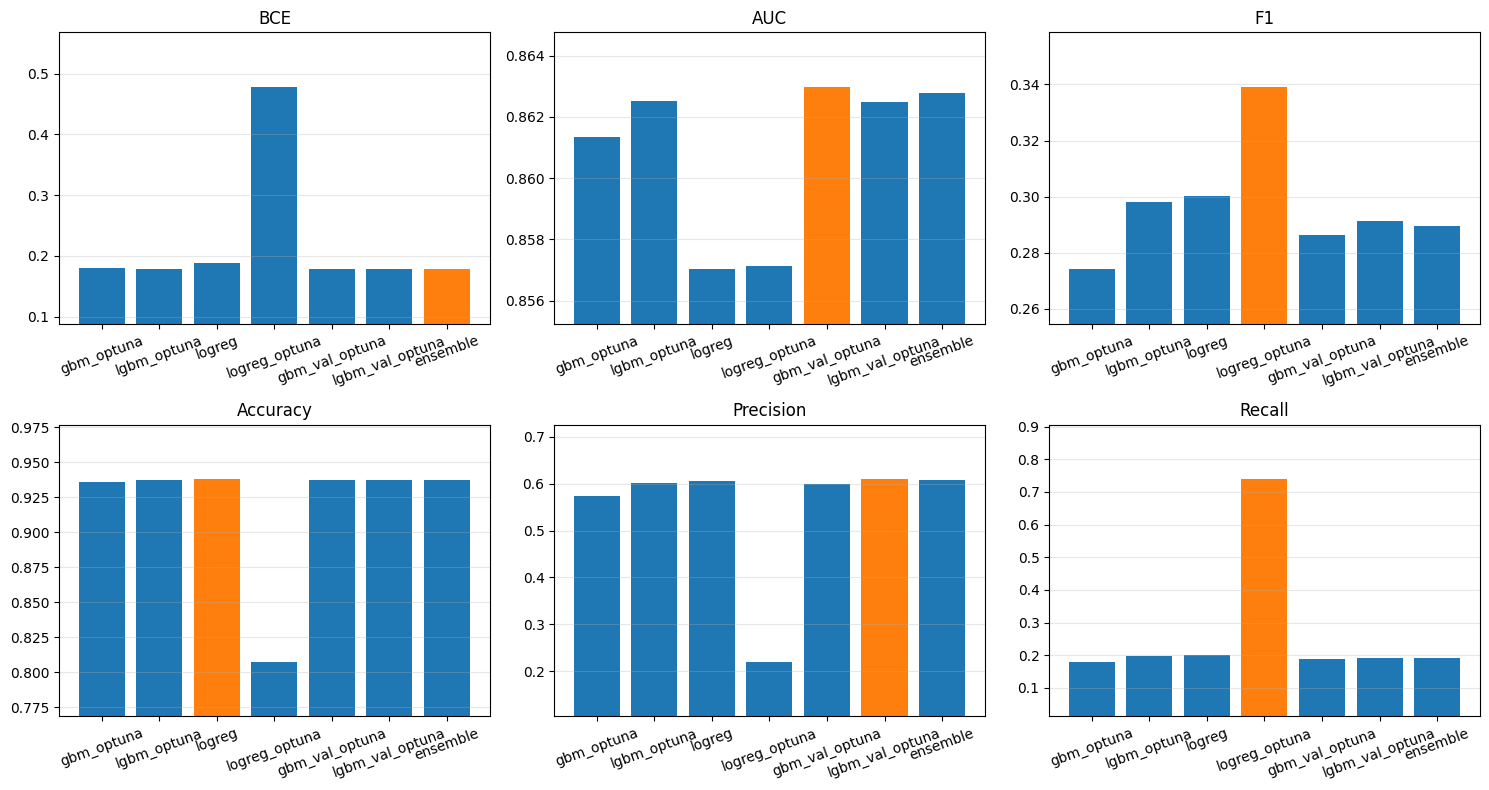

In [88]:
metrics_dict['ensemble'] = ensemble_metrics
plot_metrics_from_dicts(metrics_dict)

In [94]:
class BoostingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        lgbm_model,
        gbm_model,
        threshold=0.5
    ):
        self.lgbm_model = lgbm_model
        self.gbm_model = gbm_model
        self.threshold = threshold

        self.w_lgbm = 0.85
        self.w_gbm = 0.15

    def predict_proba(self, X):
        probs = []

        p_lgbm = self.lgbm_model.predict_proba(X)[:, 1]
        p_gbm = self.gbm_model.predict_proba(X)[:, 1]

        final_prob = (
            self.w_lgbm * p_lgbm +
            self.w_gbm * p_gbm
        )

        return np.column_stack([1 - final_prob, final_prob])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)

In [95]:
boosting_ensemble = BoostingClassifier(
    lgbm_model=lgbm_val_pipe_optuna, 
    gbm_model=gbm_val_pipe_optuna
)

In [96]:
boosting_ensemble_metrics = evaluate_model(
    boosting_ensemble,
    X_fe2_fs_test,
    y_fe2_fs_test
)

pprint(boosting_ensemble_metrics)

{'AUC': 0.8627623758375456,
 'Accuracy': 0.9376444444444444,
 'BCE': 0.17797288615364212,
 'F1': 0.289620253164557,
 'Precision': 0.6072186836518046,
 'Recall': 0.1901595744680851}


In [97]:
joblib.dump(boosting_ensemble, 'models/Ensemble/boosting_ensemble.pkl')

['models/Ensemble/boosting_ensemble.pkl']